# Dataset Selection

Dataset: Animals-10
Animal Dataset
Link: https://www.kaggle.com/datasets/alessiocorrado99/animals10/data?select=raw-img

Pre-processing
- Removed the spider and butterfly images.

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset

# Dataset path
dataset_path = "raw-img"

IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Take only 20% of dataset
indices = np.random.choice(len(full_dataset), size=int(0.3 * len(full_dataset)), replace=False)
small_dataset = Subset(full_dataset, indices)

# Split into train/val
train_size = int(0.7 * len(small_dataset))
temp_size = len(small_dataset) - train_size
val_size = (int)(temp_size/2)
test_size = temp_size - val_size
train_dataset, val_dataset, test_dataset = random_split(small_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = full_dataset.classes
print("Classes:", class_names)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('Labels:', [class_names[i] for i in labels])


#### CNN Design
The plan is to build a Conv2d -> ReLU -> MaxPool where we increase the channels gradually.

There will be 3 convolution layers with filter size 32, 64, and 128.

There will also be 2 MaxPooling layers to reduce spatial size and prevent overfitting.

The reason I chose to use 3 conv layers of size 32 -> 64 -> 128 was to extract the features progressively. 

I also chose to use around 30% of the original dataset. The reason for this is soley for how long it would take to run my models on over a 20k images.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256)  # after 3 poolings
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

num_classes = len(class_names)
model = CNN(num_classes)


In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy= correct / total
    return total_loss / len(dataloader), accuracy


#### Training

In [ ]:
import torch.optim as optim
import torch
import sys

#Some testing to make sure this runs on my GPU and not my CPU
print(sys.executable)

print("Torch version:", torch.__version__)
print("CUDA available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)


device = torch.device("cuda")
model = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_accuracies = []

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/10, Loss: {train_loss:.3f}, Val Acc: {val_acc:.2f}%")


C:\Users\Neil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Torch version: 2.5.1+cu121
CUDA available? True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
CUDA version: 12.1
Epoch 1/10, Loss: 1.862, Val Acc: 31.41%
Epoch 2/10, Loss: 1.580, Val Acc: 42.38%
Epoch 3/10, Loss: 1.341, Val Acc: 46.77%
Epoch 4/10, Loss: 1.057, Val Acc: 52.08%
Epoch 5/10, Loss: 0.736, Val Acc: 50.92%
Epoch 6/10, Loss: 0.388, Val Acc: 53.58%
Epoch 7/10, Loss: 0.155, Val Acc: 52.08%
Epoch 8/10, Loss: 0.071, Val Acc: 51.96%
Epoch 9/10, Loss: 0.049, Val Acc: 50.23%
Epoch 10/10, Loss: 0.030, Val Acc: 51.73%


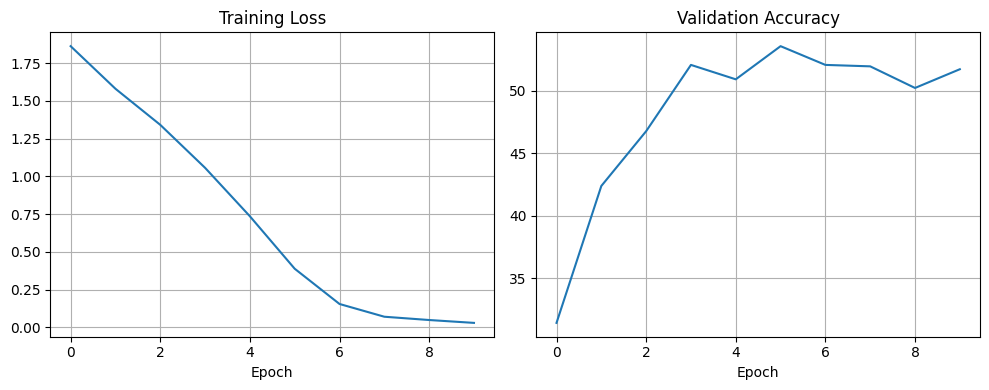

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.5323


Next up, I'll try out ResNet50.

In [ ]:
from torchvision import models

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

train_losses = []
val_accuracies = []

for epoch in range(10):
    resnet.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    resnet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/10, Loss: {train_losses:.4f}, Val Acc: {val_acc:.2f}%")

KeyboardInterrupt: 

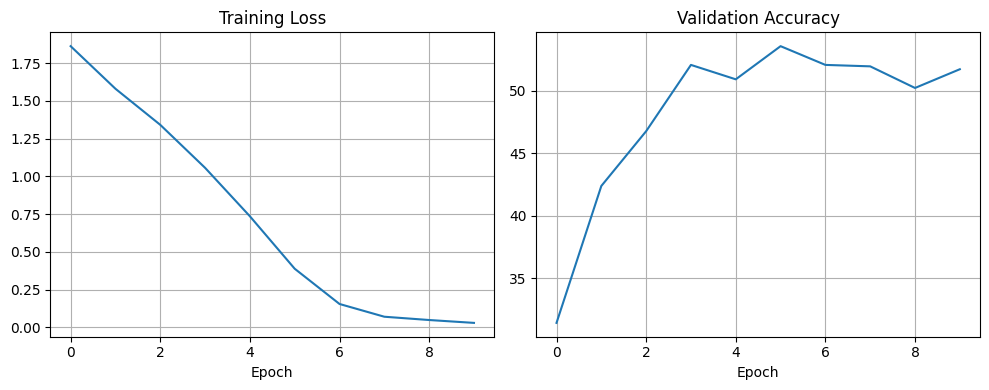

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.grid()

plt.tight_layout()
plt.show()

We're getting about 89% accuracy on the validation dataset. Lets test to see what it is like on the test dataset.

In [ ]:
test_loss, test_acc = evaluate(resnet, test_loader, criterion)
print(f"Final Test Accuracy: {test_acc:.4f}")

According to the results of the ResNet50 model, we had around a 90% accuracy on this dataset. There are some major differences as the validation and test accuracy are both a lot better. 

Next up, lets provide some transformations to the images and then retrain them.

In [ ]:
dataset_path = "raw-img"
IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

full_dataset = datasets.ImageFolder(root=dataset_path, transform=test_transform)
augmented_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)

indices = np.random.choice(len(full_dataset), size=int(0.3 * len(full_dataset)), replace=False)
small_dataset = Subset(full_dataset, indices)
aug_small_dataset = Subset(augmented_dataset, indices)

train_size = int(0.8 * len(small_dataset))
temp_size = len(small_dataset) - train_size
val_size = temp_size // 2
test_size = temp_size - val_size

train_dataset, _ = random_split(aug_small_dataset, [train_size, temp_size])   # augmented
_, temp_dataset = random_split(small_dataset, [train_size, temp_size])       # non-aug
val_dataset, test_dataset = random_split(temp_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(full_dataset.classes)
print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horses', 'sheep', 'squirrel']
Train: 4618, Val: 577, Test: 578


In [ ]:
device = torch.device("cuda")

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in resnet.parameters():
    param.requires_grad = False  # freeze backbone
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

def evaluate(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):
    resnet.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    loss = running_loss/len(train_loader)
    train_acc = evaluate(train_loader, resnet)
    val_acc = evaluate(val_loader, resnet)

    train_losses.append(loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/10 "
          f"Loss: {loss:.4f}, "
          f"Train Acc: {train_acc:.2f}%, "
          f"Val Acc: {val_acc:.2f}%")

Epoch 1/10 Loss: 0.8036, Train Acc: 82.57%, Val Acc: 81.28%, Test Acc: 83.22%
Epoch 2/10 Loss: 0.5438, Train Acc: 84.97%, Val Acc: 84.75%, Test Acc: 86.51%
Epoch 3/10 Loss: 0.4745, Train Acc: 85.97%, Val Acc: 84.23%, Test Acc: 84.78%
Epoch 4/10 Loss: 0.4730, Train Acc: 87.01%, Val Acc: 88.21%, Test Acc: 88.06%
Epoch 5/10 Loss: 0.4456, Train Acc: 87.83%, Val Acc: 87.35%, Test Acc: 87.54%
Epoch 6/10 Loss: 0.4739, Train Acc: 87.44%, Val Acc: 87.87%, Test Acc: 86.85%
Epoch 7/10 Loss: 0.4306, Train Acc: 88.41%, Val Acc: 88.56%, Test Acc: 88.24%
Epoch 8/10 Loss: 0.4515, Train Acc: 87.81%, Val Acc: 88.04%, Test Acc: 85.64%


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid()

plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = evaluate(resnet, test_loader, criterion)
print(f"Final Test Accuracy: {test_acc:.4f}")

After doing transforming the data, I noticed that the maximum accuracy improved significantly for all the models I trained for.